# 4D Phantom: Test Individual `invert` Solvers

This notebook runs one `invert` solver at a time on the MNE 4D BTi phantom dataset and reports localization error against known dipole locations.

You can switch the solver by changing `SOLVER_NAME` in the config cell.


In [17]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import os.path as op

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

from invert import Solver
from mne.datasets import phantom_4dbti


## Config


In [19]:
SOLVER_NAME = "lcmv"  # e.g. "mne", "wmne", "loreta", "esmv", ...
SOLVER_KWARGS = {}

RUN_IDS = [1, 2, 3, 4]
RAW_TEMPLATE = "{run_id}/e,rfhp1.0Hz"
BAD_CHANNELS = ["A173", "A213", "A232"]
EVENT_CHANNEL = "TRIGGER"
EVENT_ID = 8192
EVENT_MASK = 4350

TMIN, TMAX = -0.2, 0.4
PEAK_TIME = 0.07  # seconds

HEAD_RADIUS = 0.080  # meters
SOURCE_RADIUS = 0.072  # meters
SOURCE_GRID_MM = 6.0
MINDIST_MM = 1.0


## Ground truth dipole locations

From the MNE phantom tutorial (converted to head coordinates, meters).


In [20]:
actual_pos = 0.01 * np.array(
    [
        [0.16, 1.61, 5.13],
        [0.17, 1.35, 4.15],
        [0.16, 1.05, 3.19],
        [0.13, 0.80, 2.26],
    ]
)
actual_pos = actual_pos @ np.array([[0, 1, 0], [-1, 0, 0], [0, 0, 1]])
actual_pos


array([[-0.0161,  0.0016,  0.0513],
       [-0.0135,  0.0017,  0.0415],
       [-0.0105,  0.0016,  0.0319],
       [-0.008 ,  0.0013,  0.0226]])

## Helper functions


In [21]:
def load_phantom_run(run_id, data_path):
    raw_fname = op.join(data_path, RAW_TEMPLATE.format(run_id=run_id))
    raw = mne.io.read_raw_bti(raw_fname, rename_channels=False, preload=True)
    raw.info["bads"] = BAD_CHANNELS

    events = mne.find_events(
        raw,
        stim_channel=EVENT_CHANNEL,
        mask=EVENT_MASK,
        mask_type="not_and",
    )
    epochs = mne.Epochs(
        raw,
        events=events,
        event_id=EVENT_ID,
        tmin=TMIN,
        tmax=TMAX,
        preload=True,
        baseline=(None, 0.0),
    )
    evoked = epochs.average()
    cov = mne.compute_covariance(epochs, tmax=0.0)
    return raw, epochs, evoked, cov


def make_sphere_forward(info):
    sphere = mne.make_sphere_model(r0=(0.0, 0.0, 0.0), head_radius=HEAD_RADIUS)
    src = mne.setup_volume_source_space(
        subject=None,
        pos=SOURCE_GRID_MM,
        sphere=(0.0, 0.0, 0.0, SOURCE_RADIUS),
        mindist=MINDIST_MM,
        exclude=0.0,
        verbose=False,
    )
    fwd = mne.make_forward_solution(
        info,
        trans=None,
        src=src,
        bem=sphere,
        meg=True,
        eeg=False,
        verbose=False,
    )
    return fwd, sphere


def source_positions_from_forward(fwd):
    return np.concatenate([s["rr"][s["vertno"]] for s in fwd["src"]], axis=0)


def estimate_peak_position_from_matrix(source_mat, fwd):
    # collapse time by max abs value, then pick strongest source
    source_power = np.max(np.abs(source_mat), axis=1)
    peak_idx = int(np.argmax(source_power))
    pos = source_positions_from_forward(fwd)[peak_idx]
    return pos, peak_idx, source_power[peak_idx]


def run_invert_solver(evoked, fwd, cov, solver_name=SOLVER_NAME, solver_kwargs=None):
    if solver_kwargs is None:
        solver_kwargs = {}

    solver = Solver(solver_name, **solver_kwargs)
    solver.make_inverse_operator(fwd, evoked, noise_cov=cov)
    stc = solver.apply_inverse_operator(evoked.copy().crop(PEAK_TIME, PEAK_TIME))
    return solver, stc


def run_mne_dipole_fit(evoked, cov, sphere):
    dip = mne.fit_dipole(evoked.copy().crop(PEAK_TIME, PEAK_TIME), cov, sphere, verbose=False)[0]
    return dip.pos[0], dip.ori[0], dip.gof[0]


## Load all runs


In [22]:
data_path = phantom_4dbti.data_path()

runs = {}
for run_id in RUN_IDS:
    raw, epochs, evoked, cov = load_phantom_run(run_id, data_path)
    fwd, sphere = make_sphere_forward(evoked.info)
    runs[run_id] = {
        "raw": raw,
        "epochs": epochs,
        "evoked": evoked,
        "cov": cov,
        "fwd": fwd,
        "sphere": sphere,
    }

print(f"Loaded {len(runs)} phantom runs")


Reading 4D PDF file /Users/lukas/mne_data/MNE-phantom-4DBTi/1/e,rfhp1.0Hz...
Creating Neuromag info structure ...
... Setting channel info structure.
... putting coil transforms in Neuromag coordinates
... Reading digitization points from /Users/lukas/mne_data/MNE-phantom-4DBTi/1/hs_file
Currently direct inclusion of 4D weight tables is not supported. For critical use cases please take into account the MNE command "mne_create_comp_data" to include weights as printed out by the 4D "print_table" routine.
Reading 0 ... 13599  =      0.000 ...    20.052 secs...
Finding events on: TRIGGER
Trigger channel TRIGGER has a non-zero initial value of 4350 (consider using initial_event=True to detect this event)
50 events found on stim channel TRIGGER
Event IDs: [8192]
Not setting metadata
50 matching events found
Setting baseline interval to [-0.2005396927425159, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 50 events and 408 origin

## Quick look at one evoked response


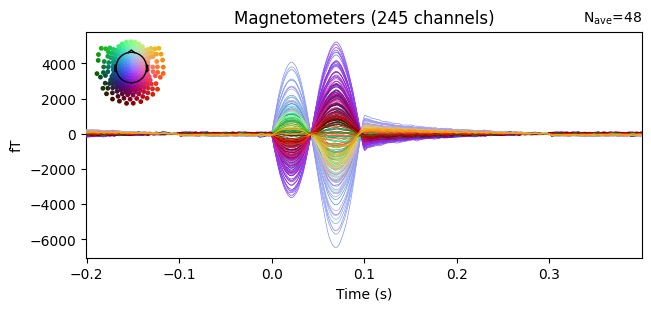

In [23]:
runs[1]["evoked"].plot(time_unit="s")
plt.show()


## Evaluate the selected `invert` solver on all 4 phantom positions


In [24]:
results = []
solver_positions = []
mne_positions = []

for run_id in RUN_IDS:
    evoked = runs[run_id]["evoked"]
    cov = runs[run_id]["cov"]
    fwd = runs[run_id]["fwd"]
    sphere = runs[run_id]["sphere"]

    # invert solver
    solver, stc = run_invert_solver(evoked, fwd, cov, SOLVER_NAME, SOLVER_KWARGS)
    pos_hat, peak_idx, peak_amp = estimate_peak_position_from_matrix(stc.data, fwd)

    # MNE dipole fit baseline from official tutorial
    dip_pos, dip_ori, dip_gof = run_mne_dipole_fit(evoked, cov, sphere)

    gt = actual_pos[run_id - 1]
    err_solver_mm = 1e3 * np.linalg.norm(pos_hat - gt)
    err_mne_mm = 1e3 * np.linalg.norm(dip_pos - gt)

    solver_positions.append(pos_hat)
    mne_positions.append(dip_pos)

    results.append(
        {
            "run": run_id,
            "solver": SOLVER_NAME,
            "solver_err_mm": err_solver_mm,
            "solver_peak_idx": peak_idx,
            "solver_peak_amp": float(peak_amp),
            "mne_dipfit_err_mm": err_mne_mm,
            "mne_dipfit_gof": float(dip_gof),
        }
    )

results_df = pd.DataFrame(results)
results_df


LCMV: noise_cov channels do not align with forward channels; falling back to Euclidean weight normalization.
LCMV: noise_cov channels do not align with forward channels; falling back to Euclidean weight normalization.
LCMV: noise_cov channels do not align with forward channels; falling back to Euclidean weight normalization.
LCMV: noise_cov channels do not align with forward channels; falling back to Euclidean weight normalization.


,run,solver,solver_err_mm,solver_peak_idx,solver_peak_amp,mne_dipfit_err_mm,mne_dipfit_gof
0,1,lcmv,5.500909,6481,1.010556e-12,1.406249,96.224918
1,2,lcmv,5.948949,5901,7.634067e-13,1.404480,93.979456
2,3,lcmv,9.231468,5186,5.686544e-13,1.184991,94.441361
3,4,lcmv,5.181699,4783,4.084745e-13,1.073803,94.941008


## Summary errors


In [25]:
summary = {
    "solver": SOLVER_NAME,
    "solver_mean_mm": results_df["solver_err_mm"].mean(),
    "solver_std_mm": results_df["solver_err_mm"].std(ddof=0),
    "mne_dipfit_mean_mm": results_df["mne_dipfit_err_mm"].mean(),
    "mne_dipfit_std_mm": results_df["mne_dipfit_err_mm"].std(ddof=0),
}
summary


{'solver': 'lcmv',
 'solver_mean_mm': np.float64(6.465756247093104),
 'solver_std_mm': np.float64(1.619875351123184),
 'mne_dipfit_mean_mm': np.float64(1.267380890808827),
 'mne_dipfit_std_mm': np.float64(0.14347577594197697)}

## 3D visualization: ground truth vs estimates

- Red: ground truth
- Yellow: `invert` solver peak location
- Cyan: MNE dipole fit


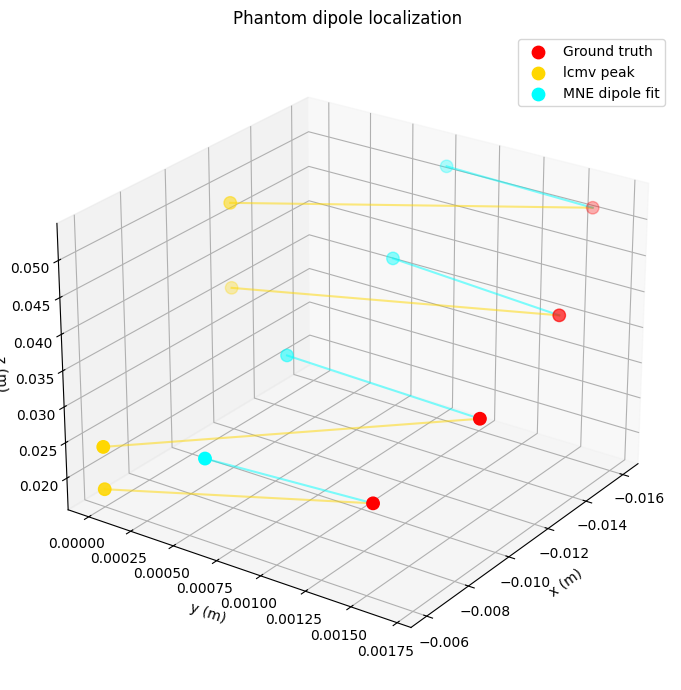

In [26]:
solver_positions = np.asarray(solver_positions)
mne_positions = np.asarray(mne_positions)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(actual_pos[:, 0], actual_pos[:, 1], actual_pos[:, 2], c="red", s=80, label="Ground truth")
ax.scatter(solver_positions[:, 0], solver_positions[:, 1], solver_positions[:, 2], c="gold", s=80, label=f"{SOLVER_NAME} peak")
ax.scatter(mne_positions[:, 0], mne_positions[:, 1], mne_positions[:, 2], c="cyan", s=80, label="MNE dipole fit")

for i in range(len(RUN_IDS)):
    ax.plot(
        [actual_pos[i, 0], solver_positions[i, 0]],
        [actual_pos[i, 1], solver_positions[i, 1]],
        [actual_pos[i, 2], solver_positions[i, 2]],
        color="gold",
        alpha=0.5,
        linewidth=1.5,
    )
    ax.plot(
        [actual_pos[i, 0], mne_positions[i, 0]],
        [actual_pos[i, 1], mne_positions[i, 1]],
        [actual_pos[i, 2], mne_positions[i, 2]],
        color="cyan",
        alpha=0.5,
        linewidth=1.5,
    )

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title("Phantom dipole localization")
ax.legend(loc="best")
ax.view_init(elev=25, azim=35)
plt.tight_layout()
plt.show()


## Next experiments

- Change `SOLVER_NAME` and rerun evaluation cells.
- Optionally tune `SOLVER_KWARGS` (e.g., regularization settings).
- Compare how close each solver gets to the MNE dipole-fit baseline and phantom ground truth.
